# Fine-tune Emotion2Vec — Nhận dạng cảm xúc tiếng Việt

**Trước khi chạy:**
1. Upload thư mục `processed/` và `splits/` lên Google Drive
2. **Runtime → Change runtime type → T4 GPU → Save**
3. Chạy từng cell từ trên xuống

In [ ]:
# CELL 1 — Cài thư viện (~2 phút)
!pip install funasr "numpy<2" soundfile librosa audiomentations -q

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.0/812.0 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 15.5 MB/s eta 0:0

In [ ]:
# CELL 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 3 — Config
# ⚠️ Chỉ cần sửa DRIVE_BASE nếu bạn để dataset_v2 trong subfolder khác
from pathlib import Path
import torch

DRIVE_BASE = Path("/content/drive/MyDrive/dataset_v2")
# Nếu để trong My Drive/GR/dataset_v2/ thì sửa thành:
# DRIVE_BASE = Path("/content/drive/MyDrive/GR/dataset_v2")

SPLITS_DIR = DRIVE_BASE / "splits"
PROC_DIR   = DRIVE_BASE / "processed"
MODEL_DIR  = DRIVE_BASE / "models"
MODEL_DIR.mkdir(exist_ok=True)

EMOTIONS    = ["angry", "fear", "happy", "neutral", "sad", "surprise"]
LABEL2ID    = {e: i for i, e in enumerate(EMOTIONS)}
NUM_CLASSES = 6
TARGET_SR   = 16_000
MAX_SEC     = 6
BATCH_SIZE  = 16
EPOCHS      = 20
LR_BACKBONE = 1e-5
LR_HEAD     = 1e-3
PATIENCE    = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {DEVICE}")
print(f"✓ Processed dir exists: {PROC_DIR.exists()}")
print(f"✓ Splits dir exists:    {SPLITS_DIR.exists()}")

✓ Device: cpu
✓ Processed dir exists: True
✓ Splits dir exists:    True


In [ ]:
# CELL 4 — Fix đường dẫn trong CSV (Mac path → Colab path)
import pandas as pd
import re

df_check    = pd.read_csv(SPLITS_DIR / "train.csv")
sample_path = df_check["path"].iloc[0]
print(f"Path gốc trong CSV: {sample_path}")

def fix_paths(df: pd.DataFrame) -> pd.DataFrame:
    def remap(p: str) -> str:
        match = re.search(r'processed[/\\](.+)', p)
        if match:
            return str(PROC_DIR / match.group(1))
        return p
    df = df.copy()
    df["path"] = df["path"].apply(remap)
    return df

fixed     = fix_paths(df_check)
test_path = Path(fixed["path"].iloc[0])
print(f"Path sau fix:       {fixed['path'].iloc[0]}")
print(f"File tồn tại:       {test_path.exists()}")

Path gốc trong CSV: /Users/nvt/Documents/GR/dataset_v2/processed/sad/sad_01095.wav
Path sau fix:       /content/drive/MyDrive/dataset_v2/processed/sad/sad_01095.wav
File tồn tại:       True


In [ ]:
# CELL 5 — Dataset & DataLoader
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class AudioDataset(Dataset):
    def __init__(self, split: str, augment: bool = False):
        df = pd.read_csv(SPLITS_DIR / f"{split}.csv")
        df = fix_paths(df)
        df = df[df["path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
        self.paths  = df["path"].tolist()
        self.labels = [LABEL2ID[e] for e in df["emotion"]]
        self.transform = None
        if augment:
            import audiomentations as A
            self.transform = A.Compose([
                A.AddGaussianNoise(p=0.3),
                A.TimeStretch(min_rate=0.85, max_rate=1.15, p=0.3),
                A.PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
            ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        audio, _ = librosa.load(self.paths[idx], sr=TARGET_SR, mono=True)
        if self.transform:
            audio = self.transform(samples=audio, sample_rate=TARGET_SR)
        max_len = TARGET_SR * MAX_SEC
        audio = audio[:max_len] if len(audio) > max_len else \
                np.pad(audio, (0, max_len - len(audio)))
        return torch.FloatTensor(audio), self.labels[idx]

train_ds = AudioDataset("train", augment=True)
val_ds   = AudioDataset("val",   augment=False)
test_ds  = AudioDataset("test",  augment=False)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

label_arr = np.array(train_ds.labels)
counts    = np.bincount(label_arr, minlength=NUM_CLASSES)
print("Phân phối train:", dict(zip(EMOTIONS, counts)))

sampler      = WeightedRandomSampler(1.0/(counts[label_arr]+1e-6), len(label_arr))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

Train: 5666  Val: 1200  Test: 1200
Phân phối train: {'angry': 946, 'fear': 936, 'happy': 946, 'neutral': 946, 'sad': 946, 'surprise': 946}


In [ ]:
# CELL 6 — Load Emotion2Vec model
import torch.nn as nn
from funasr import AutoModel

class Emotion2VecSER(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        print("Tải Emotion2Vec_plus_base từ HuggingFace (~360MB)...")
        _m = AutoModel(model="iic/emotion2vec_plus_base", model_hub="hf", disable_update=True)
        self.backbone = _m.model
        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, wav):
        # features_only=True → backbone trả dict {"x": tensor, ...}
        # thay vì chạy SSL head (trả None khi fine-tune)
        out = self.backbone(wav, features_only=True)
        if isinstance(out, dict):
            hidden = out["x"]
        elif hasattr(out, "last_hidden_state"):
            hidden = out.last_hidden_state
        elif isinstance(out, (tuple, list)):
            hidden = out[0]
        else:
            hidden = out
        return self.head(hidden.mean(dim=1))

model = Emotion2VecSER(NUM_CLASSES).to(DEVICE)
print(f"✓ Model loaded — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Tải Emotion2Vec_plus_base từ HuggingFace (~360MB)...
funasr version: 1.3.1.


2026-04-19 09:21:52,614 - modelscope - INFO - Got 10 files, start to download ...


Processing 10 items:   0%|          | 0.00/10.0 [00:00<?, ?it/s]

2026-04-19 09:26:29,233 - modelscope - INFO - Download model 'iic/emotion2vec_plus_base' successfully.


Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.3.0.weight, /root/.cache/modelscope/hub/models/iic/e

In [ ]:
# CELL 6.5 — Patch funasr bugs + reload model
import importlib, types, gc, torch, subprocess

# ── Bước 0: reinstall funasr để lấy file modules.py sạch ─────────────
print('Reinstalling funasr...')
subprocess.run(['pip', 'install', '--force-reinstall', '--no-deps', 'funasr', '-q'], check=True)
print('\u2713 funasr reinstalled')

# ── Patch 1: fix ALiBi — thay condition if alibi_bias ────────────────
import funasr.models.emotion2vec.modules as _m
_path = _m.__file__
with open(_path) as f: _src = f.read()
_old = 'if alibi_bias is not None:'
_new = 'if alibi_bias is not None and alibi_bias.size(0) == attn.size(0):'
if _old in _src:
    with open(_path, 'w') as f: f.write(_src.replace(_old, _new, 1))
    print(f'\u2713 Patch 1: ALiBi fixed')
else:
    print('  Patch 1: line not found')

# ── Patch 2: disable mask ─────────────────────────────────────────────
def _no_mask_fwd(self, source, padding_mask=None, mask=True,
                 features_only=False, output_layer=None,
                 output_hidden_states=False, **kw):
    return self._orig_fwd(source, padding_mask=padding_mask, mask=False,
                          features_only=features_only, output_layer=output_layer,
                          output_hidden_states=output_hidden_states, **kw)

# ── Reload + recreate model ───────────────────────────────────────────
import funasr.models.emotion2vec.base as _base
importlib.reload(_m)
importlib.reload(_base)
del model; gc.collect()

model = Emotion2VecSER(NUM_CLASSES).to(DEVICE)
model.backbone._orig_fwd = model.backbone.forward
model.backbone.forward = types.MethodType(_no_mask_fwd, model.backbone)
print(f'\u2713 Patch 2: mask disabled')
print(f'\u2713 Model ready \u2014 {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')


Reinstalling funasr...
✓ funasr reinstalled
✓ Patch 1: ALiBi fixed
Tải Emotion2Vec_plus_base từ HuggingFace (~360MB)...
funasr version: 1.3.1.


Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_base/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.3.0.weight, /root/.cache/modelscope/hub/models/iic/e

In [ ]:
# CELL 7 — Training
from tqdm import tqdm

optimizer = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": LR_BACKBONE},
    {"params": model.head.parameters(),     "lr": LR_HEAD},
], weight_decay=1e-2)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
class_w   = torch.FloatTensor(1.0/(counts/counts.sum()+1e-6)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_w/class_w.sum())

best_acc  = 0.0
patience  = 0
best_path = MODEL_DIR / "emotion2vec_viet_finetuned.pt"

print(f"{'Ep':>3} {'T_Loss':>8} {'T_Acc':>7} {'V_Acc':>7}  Status")
print("-" * 50)

for epoch in range(1, EPOCHS+1):
    model.train()
    t_loss, t_cor, n = 0, 0, 0
    for wav, lbl in tqdm(train_loader, desc=f"Ep{epoch:02d}", leave=False, ncols=70):
        wav, lbl = wav.to(DEVICE), lbl.to(DEVICE)
        logits   = model(wav)
        loss     = criterion(logits, lbl)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()*len(lbl)
        t_cor  += (logits.argmax(1)==lbl).sum().item()
        n      += len(lbl)
    t_loss /= n; t_acc = t_cor/n

    model.eval(); v_cor = v_n = 0
    with torch.no_grad():
        for wav, lbl in val_loader:
            wav, lbl = wav.to(DEVICE), lbl.to(DEVICE)
            v_cor += (model(wav).argmax(1)==lbl).sum().item()
            v_n   += len(lbl)
    v_acc = v_cor/v_n
    scheduler.step()

    if v_acc > best_acc:
        best_acc = v_acc; patience = 0
        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "val_acc": v_acc, "emotions": EMOTIONS}, best_path)
        status = f"✓ best={best_acc:.4f}"
    else:
        patience += 1
        status = f"  pat {patience}/{PATIENCE}"

    print(f"{epoch:>3}  {t_loss:>8.4f}  {t_acc:>6.4f}  {v_acc:>6.4f}  {status}")
    if patience >= PATIENCE:
        print(f"Early stopping tại epoch {epoch}"); break

print(f"\n✓ Best val accuracy: {best_acc*100:.2f}%")
print(f"  Saved: {best_path}")

 Ep   T_Loss   T_Acc   V_Acc  Status
--------------------------------------------------


  1    1.4085  0.4070  0.5692  ✓ best=0.5692


  2    1.0093  0.5994  0.6667  ✓ best=0.6667


  3    0.8792  0.6475  0.6875  ✓ best=0.6875


  4    0.8047  0.6828  0.7100  ✓ best=0.7100


...

 14    0.4287  0.8463  0.7758    pat 1/5


 15    0.3902  0.8602  0.7758    pat 2/5


 16    0.3678  0.8630  0.7733    pat 3/5


 17    0.3786  0.8597  0.7808    pat 4/5


 18    0.3662  0.8697  0.7817    pat 5/5
Early stopping tại epoch 18

✓ Best val accuracy: 78.42%
  Saved: /content/drive/MyDrive/dataset_v2/models/emotion2vec_viet_finetuned.pt


In [ ]:
# CELL 8 — Evaluate trên test set
import torch, numpy as np
from tqdm import tqdm
from pathlib import Path
MODEL_DIR = Path('/content/drive/MyDrive/dataset_v2/models')
best_path = MODEL_DIR / 'emotion2vec_viet_finetuned.pt'

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for wav, lbl in tqdm(test_loader, desc='Evaluating', ncols=70):
        all_pred.extend(model(wav.to(DEVICE)).argmax(1).cpu().numpy())
        all_true.extend(lbl.numpy())

y_true = np.array(all_true); y_pred = np.array(all_pred)
acc    = (y_true==y_pred).mean()

print(f"\n{'='*50}")
print(f"  Test Accuracy: {acc*100:.2f}%")
print(f"{'='*50}")
print(f"\n{'Class':12s} {'F1':>6}  {'Recall':>7}  Support")
print('-' * 38)
for i, emo in enumerate(EMOTIONS):
    mask = y_true==i
    tp   = ((y_pred==i)& mask).sum()
    fp   = ((y_pred==i)&~mask).sum()
    fn   = ((y_pred!=i)& mask).sum()
    p    = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    f1   = 2*p*r/(p+r+1e-9)
    ok   = '\u2713' if f1>=0.8 else ('\u26a0' if f1>=0.6 else '\u2717')
    print(f"{ok} {emo:10s} {f1*100:5.1f}%   {r*100:5.1f}%   {mask.sum()}")


Evaluating: 100%|█████████████████████| 75/75 [51:44<00:00, 41.40s/it]


  Test Accuracy: 75.42%

Class            F1   Recall  Support
--------------------------------------
⚠ angry       75.9%    81.0%   200
✓ fear        88.7%    94.5%   200
⚠ happy       68.7%    66.5%   200
✗ neutral     51.8%    50.0%   200
⚠ sad         75.5%    72.5%   200
✓ surprise    90.3%    88.0%   200


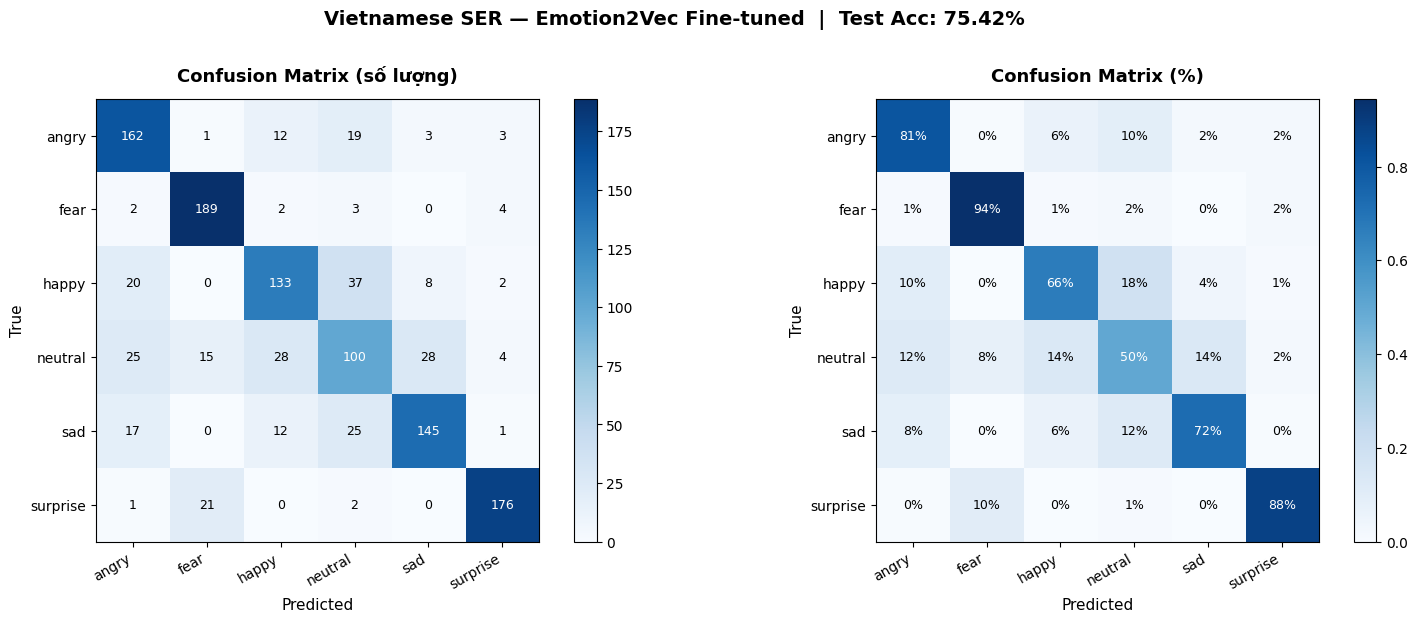

✓ Saved: confusion_matrix.png


In [ ]:
# CELL 10 — Confusion Matrix
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize theo row

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix (số lượng)', 'Confusion Matrix (%)'],
    ['d', '.0%']
):
    im = ax.imshow(data, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_xticks(range(len(EMOTIONS)))
    ax.set_yticks(range(len(EMOTIONS)))
    ax.set_xticklabels(EMOTIONS, rotation=30, ha='right')
    ax.set_yticklabels(EMOTIONS)
    plt.colorbar(im, ax=ax)
    thresh = data.max() / 2
    for i in range(len(EMOTIONS)):
        for j in range(len(EMOTIONS)):
            val = format(data[i, j], fmt)
            ax.text(j, i, val, ha='center', va='center', fontsize=9,
                    color='white' if data[i, j] > thresh else 'black')

plt.suptitle(f'Vietnamese SER — Emotion2Vec Fine-tuned  |  Test Acc: {acc*100:.2f}%',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset_v2/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 Saved: confusion_matrix.png')
